In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries loaded")

Libraries loaded


In [2]:
# Load model and scaler
rf_model = joblib.load('../models/rf_ids_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Load processed data
X_test  = np.load('../data/X_test.npy')
y_test  = np.load('../data/y_test.npy')

print("Model loaded:", rf_model)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Model loaded: RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)
X_test shape: (22544, 41)
y_test shape: (22544,)


In [3]:
# We only want to attack samples that are actual attacks
# (label=1) and that the model currently detects correctly
attack_mask      = (y_test == 1)
X_attacks        = X_test[attack_mask]
y_attacks        = y_test[attack_mask]

# Further filter: only ones the model currently catches
y_pred_attacks   = rf_model.predict(X_attacks)
detected_mask    = (y_pred_attacks == 1)

X_detected       = X_attacks[detected_mask]
y_detected       = y_attacks[detected_mask]

print(f"Total test samples:              {len(X_test)}")
print(f"Total attack samples:            {len(X_attacks)}")
print(f"Attacks currently detected:      {len(X_detected)}")
print(f"Attacks already evading (free):  {len(X_attacks) - len(X_detected)}")

Total test samples:              22544
Total attack samples:            12833
Attacks currently detected:      7990
Attacks already evading (free):  4843


In [4]:
# These are the 41 NSL-KDD features in order
feature_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate'
]

# Binary features — can only be 0 or 1, never perturb these
binary_features = [
    'land', 'logged_in', 'root_shell', 'su_attempted',
    'is_host_login', 'is_guest_login'
]
binary_indices = [feature_names.index(f) for f in binary_features]

# Rate features — must stay between 0.0 and 1.0
rate_features = [f for f in feature_names if 'rate' in f]
rate_indices  = [feature_names.index(f) for f in rate_features]

# Count features — must stay >= 0
count_indices = [i for i in range(len(feature_names))
                 if i not in binary_indices + rate_indices]

print(f"Binary features (locked):  {len(binary_indices)}")
print(f"Rate features (0.0-1.0):   {len(rate_indices)}")
print(f"Count features (>= 0):     {len(count_indices)}")
print("\nFeature constraints defined")

Binary features (locked):  6
Rate features (0.0-1.0):   15
Count features (>= 0):     20

Feature constraints defined


In [5]:
def enforce_constraints(X_adv, X_original):
    """
    After perturbation, snap features back to valid ranges.
    This ensures adversarial examples represent real network traffic.
    """
    X_adv = X_adv.copy()

    for i in range(X_adv.shape[0]):
        # Binary features: round to nearest 0 or 1
        X_adv[i, binary_indices] = np.round(
            np.clip(X_adv[i, binary_indices], 0, 1)
        )

        # Rate features: clip between 0.0 and 1.0
        X_adv[i, rate_indices] = np.clip(
            X_adv[i, rate_indices], 0.0, 1.0
        )

        # Count features: must be >= 0
        X_adv[i, count_indices] = np.clip(
            X_adv[i, count_indices], 0, None
        )

    return X_adv

print("Constraint function defined")

Constraint function defined


In [7]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

from joblib import parallel_backend

def fgsm_attack(X, epsilon=0.1):
    """
    Fast Gradient Sign Method — perturbs features in the direction
    that maximally increases the model's prediction error.
    epsilon = how big the perturbation step is
    """
    X_adv = X.copy()

    with parallel_backend('threading', n_jobs=1):
        for i in range(len(X)):
            sample = X[i].copy()

            proba = rf_model.predict_proba([sample])[0]

            if proba[1] > 0.5:
                gradient = np.zeros(len(sample))

                for j in range(len(sample)):
                    if j in binary_indices:
                        continue

                    perturbed = sample.copy()
                    perturbed[j] += 0.01
                    prob_plus = rf_model.predict_proba([perturbed])[0][1]

                    perturbed[j] -= 0.02
                    prob_minus = rf_model.predict_proba([perturbed])[0][1]

                    gradient[j] = (prob_plus - prob_minus) / 0.02

                X_adv[i] = sample - epsilon * np.sign(gradient)

    X_adv = enforce_constraints(X_adv, X)
    return X_adv

print("FGSM attack function defined")

FGSM attack function defined


In [8]:
# Use first 100 detected attacks for testing
sample_size = 100
X_sample    = X_detected[:sample_size]
y_sample    = y_detected[:sample_size]

print(f"Running FGSM on {sample_size} detected attack samples...")
print("This will take 1-2 minutes...")

X_adv_fgsm  = fgsm_attack(X_sample, epsilon=0.1)

y_pred_before = rf_model.predict(X_sample)
y_pred_after  = rf_model.predict(X_adv_fgsm)

detected_before = np.sum(y_pred_before == 1)
detected_after  = np.sum(y_pred_after == 1)
evaded          = detected_before - detected_after
evasion_rate    = (evaded / detected_before) * 100

print(f"\n{'='*45}")
print(f"FGSM Attack Results (epsilon=0.1)")
print(f"{'='*45}")
print(f"Attacks detected BEFORE:  {detected_before}/{sample_size}")
print(f"Attacks detected AFTER:   {detected_after}/{sample_size}")
print(f"Attacks that evaded:      {evaded}")
print(f"Evasion rate:             {evasion_rate:.2f}%")
print(f"{'='*45}")

Running FGSM on 100 detected attack samples...
This will take 1-2 minutes...

FGSM Attack Results (epsilon=0.1)
Attacks detected BEFORE:  100/100
Attacks detected AFTER:   0/100
Attacks that evaded:      100
Evasion rate:             100.00%


Testing different perturbation strengths (epsilon)...

epsilon=0.05 → evasion rate: 100.00%
epsilon=0.10 → evasion rate: 100.00%
epsilon=0.20 → evasion rate: 100.00%
epsilon=0.30 → evasion rate: 100.00%
epsilon=0.50 → evasion rate: 100.00%


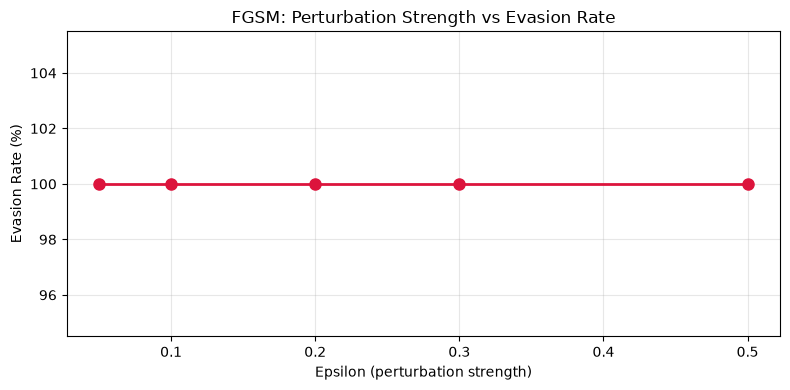

Plot saved to results/


In [9]:
epsilons      = [0.05, 0.1, 0.2, 0.3, 0.5]
evasion_rates = []

print("Testing different perturbation strengths (epsilon)...\n")

with parallel_backend('threading', n_jobs=1):
    for eps in epsilons:
        X_adv_temp  = fgsm_attack(X_sample, epsilon=eps)
        y_pred_temp = rf_model.predict(X_adv_temp)
        detected    = np.sum(y_pred_temp == 1)
        rate        = ((sample_size - detected) / sample_size) * 100
        evasion_rates.append(rate)
        print(f"epsilon={eps:.2f} → evasion rate: {rate:.2f}%")

plt.figure(figsize=(8,4))
plt.plot(epsilons, evasion_rates, 'o-', color='crimson', linewidth=2, markersize=8)
plt.xlabel('Epsilon (perturbation strength)')
plt.ylabel('Evasion Rate (%)')
plt.title('FGSM: Perturbation Strength vs Evasion Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/fgsm_epsilon_vs_evasion.png', dpi=150)
plt.show()
print("Plot saved to results/")

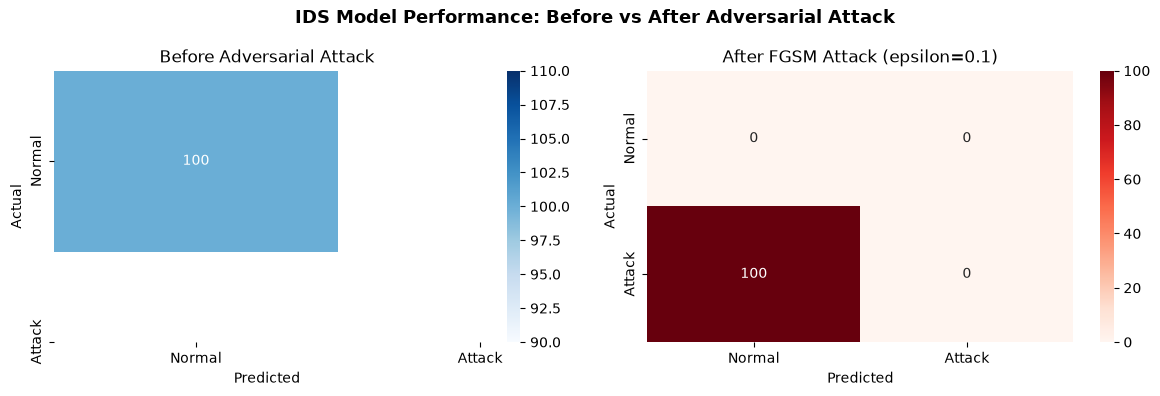

Saved to results/


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before attack
cm_before = confusion_matrix(y_sample, y_pred_before)
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[0].set_title('Before Adversarial Attack')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# After attack
cm_after = confusion_matrix(y_sample, y_pred_after)
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[1].set_title('After FGSM Attack (epsilon=0.1)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('IDS Model Performance: Before vs After Adversarial Attack', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confusion_before_after_fgsm.png', dpi=150)
plt.show()
print("Saved to results/")

In [12]:
import os
os.makedirs('../results', exist_ok=True)

np.save('../data/X_adv_fgsm.npy',     X_adv_fgsm)
np.save('../data/X_original_sample.npy', X_sample)
np.save('../data/y_sample.npy',          y_sample)

# Save evasion summary
summary = {
    'epsilon':        0.1,
    'sample_size':    sample_size,
    'detected_before': int(detected_before),
    'detected_after':  int(detected_after),
    'evasion_rate':    round(evasion_rate, 2),
    'epsilons':        epsilons,
    'evasion_rates':   evasion_rates
}

import json
with open('../results/fgsm_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Adversarial examples saved to data/X_adv_fgsm.npy")
print("Evasion summary saved to results/fgsm_summary.json")
print("\nPhase 3 complete — ready for Phase 4")

Adversarial examples saved to data/X_adv_fgsm.npy
Evasion summary saved to results/fgsm_summary.json

Phase 3 complete — ready for Phase 4
